# Machine Learning Fundamentals

## Week 1
## Task 1 – Exploratory Data Analysis (EDA)

**Dataset:** Titanic - Machine Learning from Disaster

**Prepared by:** Abdul Raheem

**Track:** Neurofive Machine Learning Track

## Objective

The objective of this notebook is to explore the Titanic dataset, understand its structure, identify missing values, distinguish numerical and categorical features, and summarize the dataset before applying any machine learning models.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the Dataset

You can use this instruction df = pd.read_csv("train.csv"), only if Python can find train.csv in the current working directory (the folder from which Jupyter is running). Means Week1_Titanic_EDA.ipynb and train.csv are in the same folder.

But if the dataset and the notebook are in different folders then ue the following approach.

In [9]:
df = pd.read_csv(r"D:\Machine Learning Fundamentals Course\Week 1\titanic\train.csv")

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
print(df.shape)

(891, 12)


In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [13]:
df.select_dtypes(include=np.number).columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [15]:
df.select_dtypes(include=['object', 'str']).columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')

## Data Story

The Titanic dataset contains information about 891 passengers and 12 different features. The dataset includes both numerical and categorical variables such as age, fare, gender, passenger class, and embarkation point. Some columns, including Age, Cabin, and Embarked, contain missing values that will require preprocessing before training machine learning models. Overall, the dataset appears well-structured and provides sufficient information for predicting passenger survival.


## Task 2 - Data Cleaning & Visualization

After understanding the dataset through Exploratory Data Analysis (EDA), the next step is to prepare the data for Machine Learning. This includes handling missing values, identifying potential outliers, and visualizing the dataset to better understand relationships among features.

The objective of this task is to clean the Titanic dataset, create meaningful visualizations, and summarize the insights obtained from the analysis.

## Handling Missing Values

Before building any Machine Learning model, missing values must be addressed because they can reduce model performance and may even prevent certain algorithms from working correctly.The assignment requires using fillna() or dropna() and justifying the choice.

First, we inspect the dataset to identify which columns contain missing values.

In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Cabin"] = df["Cabin"].fillna("Unknown")

### Why was `fillna()` used?

Instead of removing rows using `dropna()`, missing values were filled because dropping rows would reduce the size of the dataset and could result in the loss of useful information.

The median was used for the **Age** column because it is less affected by extreme values than the mean. The mode was used for **Embarked** because it is a categorical feature. Missing values in **Cabin** were replaced with "Unknown" since most cabin entries are unavailable.
Now Verify the Missing Values again.

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

## Histogram

A histogram illustrates the distribution of passenger ages.

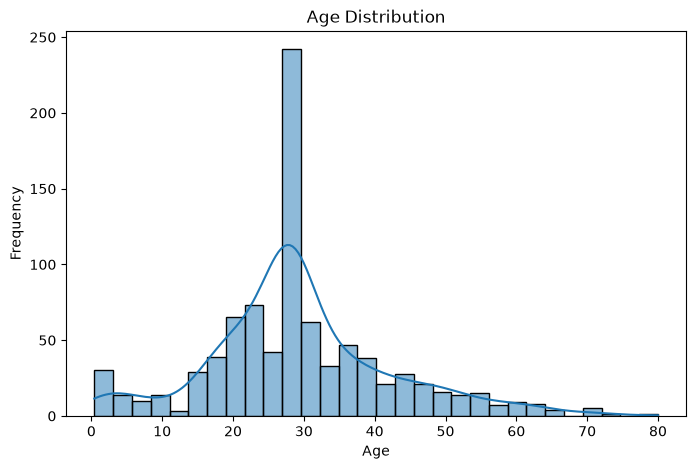

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## Outlier Detection

A boxplot is used to identify potential outliers in passenger fares.

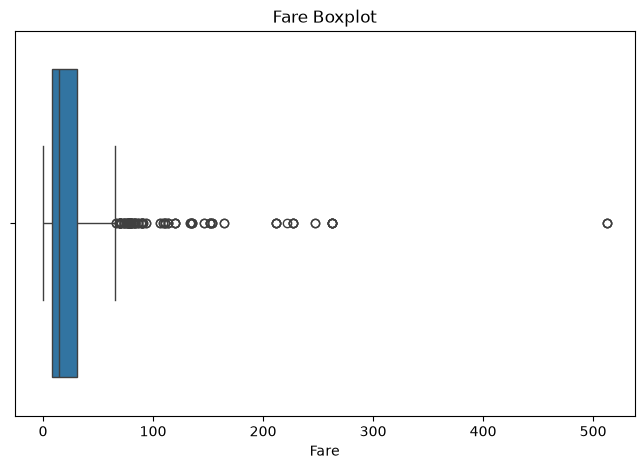

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

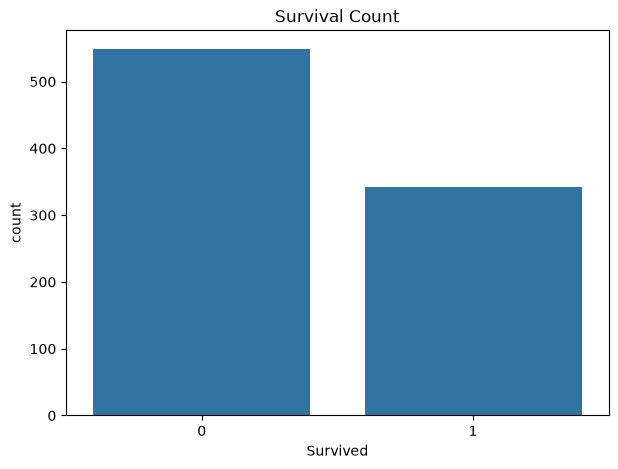

In [16]:
plt.figure(figsize=(7,5))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

In [17]:
df_encoded = df.copy()
df_encoded["Sex"] = df_encoded["Sex"].map({"male":0,"female":1})
df_encoded["Embarked"] = df_encoded["Embarked"].map({"S":0,"C":1,"Q":2})

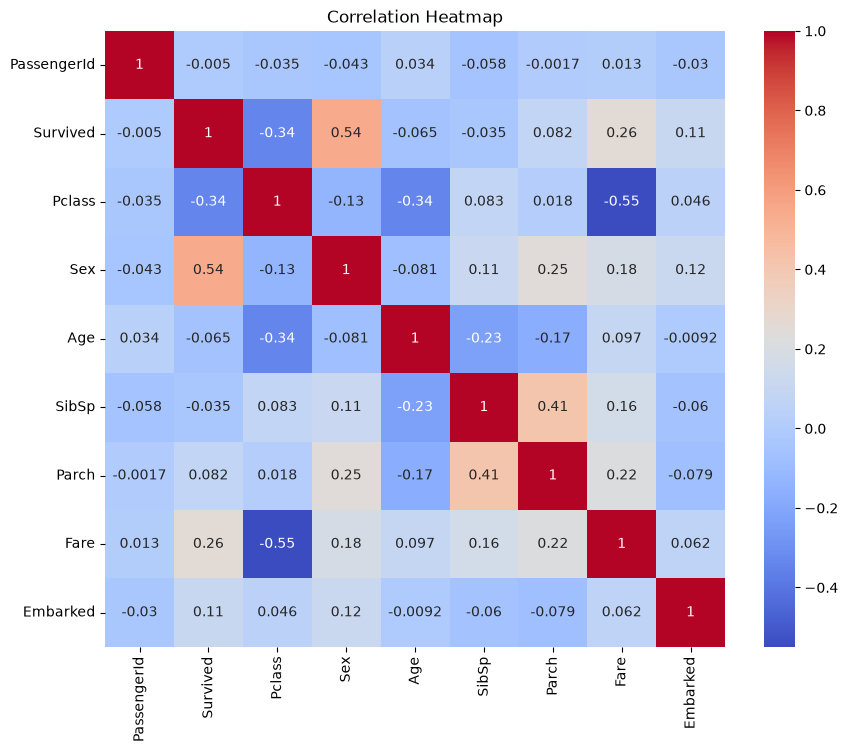

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Which feature most affects survival?

Based on the visualizations and correlation analysis, **Sex** appears to have the strongest influence on passenger survival. Female passengers had a noticeably higher survival rate than male passengers. This aligns with the historical "women and children first" evacuation policy followed during the Titanic disaster.

Passenger class (Pclass) also shows a significant relationship with survival, indicating that first-class passengers generally had a higher chance of surviving than those in lower classes.

# Conclusion

The Titanic dataset was successfully cleaned by handling missing values using appropriate techniques for numerical and categorical features. Visualizations provided valuable insights into the distribution of data, potential outliers, and relationships among variables.

The analysis indicates that passenger gender and class were among the most influential factors affecting survival. These findings provide a solid foundation for the predictive modeling tasks in the upcoming weeks.